In [1]:
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

RESULTS_DIR = Path("..") / "results"
EXPERIMENTS = ["experiment2", "experiment3"]   # NEW
FIGURES_DIR = Path(".") / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

SKIP_EMBEDDING_LAYER = True

def layer_curve(accs_test):
    curve = accs_test.mean(axis=(1, 2))
    if SKIP_EMBEDDING_LAYER:
        curve = curve[1:]
    return curve

def layer_indices(n_layers):
    return np.arange(1, n_layers + 1) if SKIP_EMBEDDING_LAYER else np.arange(n_layers)

In [2]:
# Parse all runs
RUN_RE = re.compile(
    r"^(?P<participant>[MP]\d+)"
    r"_qwen3-4b-(?P<model>llm|embedding)"
    r"(?:_(?P<pooling>mean|last))?"
    r"_passages$"
)

def load_run(run_dir):
    path = run_dir / "layer_accuracies.npz"
    if not path.exists():
        return None
    return np.load(path)["accs_test"]

runs = {}   # (experiment, participant, model, pooling) -> accs_test
for exp in EXPERIMENTS:
    exp_dir = RESULTS_DIR / exp
    if not exp_dir.exists():
        print(f"Missing experiment dir: {exp_dir}")
        continue
    for d in sorted(exp_dir.iterdir()):
        if not d.is_dir():
            continue
        m = RUN_RE.match(d.name)
        if not m:
            print(f"Skipping unrecognised dir: {exp}/{d.name}")
            continue
        accs = load_run(d)
        if accs is None:
            print(f"Missing layer_accuracies.npz in {exp}/{d.name}")
            continue
        key = (exp, m["participant"], m["model"], m["pooling"] or "default")
        runs[key] = accs

print(f"Loaded {len(runs)} runs")
experiments = sorted({k[0] for k in runs})
participants = sorted({k[1] for k in runs})
models = sorted({k[2] for k in runs})
poolings = sorted({k[3] for k in runs})
print(f"Experiments: {experiments}")
print(f"Participants: {participants}")
print(f"Models: {models}")
print(f"Poolings: {poolings}")

Loaded 28 runs
Experiments: ['experiment2', 'experiment3']
Participants: ['M02', 'M03', 'M04', 'M07', 'M08', 'M09', 'M14', 'M15', 'P01']
Models: ['embedding', 'llm']
Poolings: ['default']


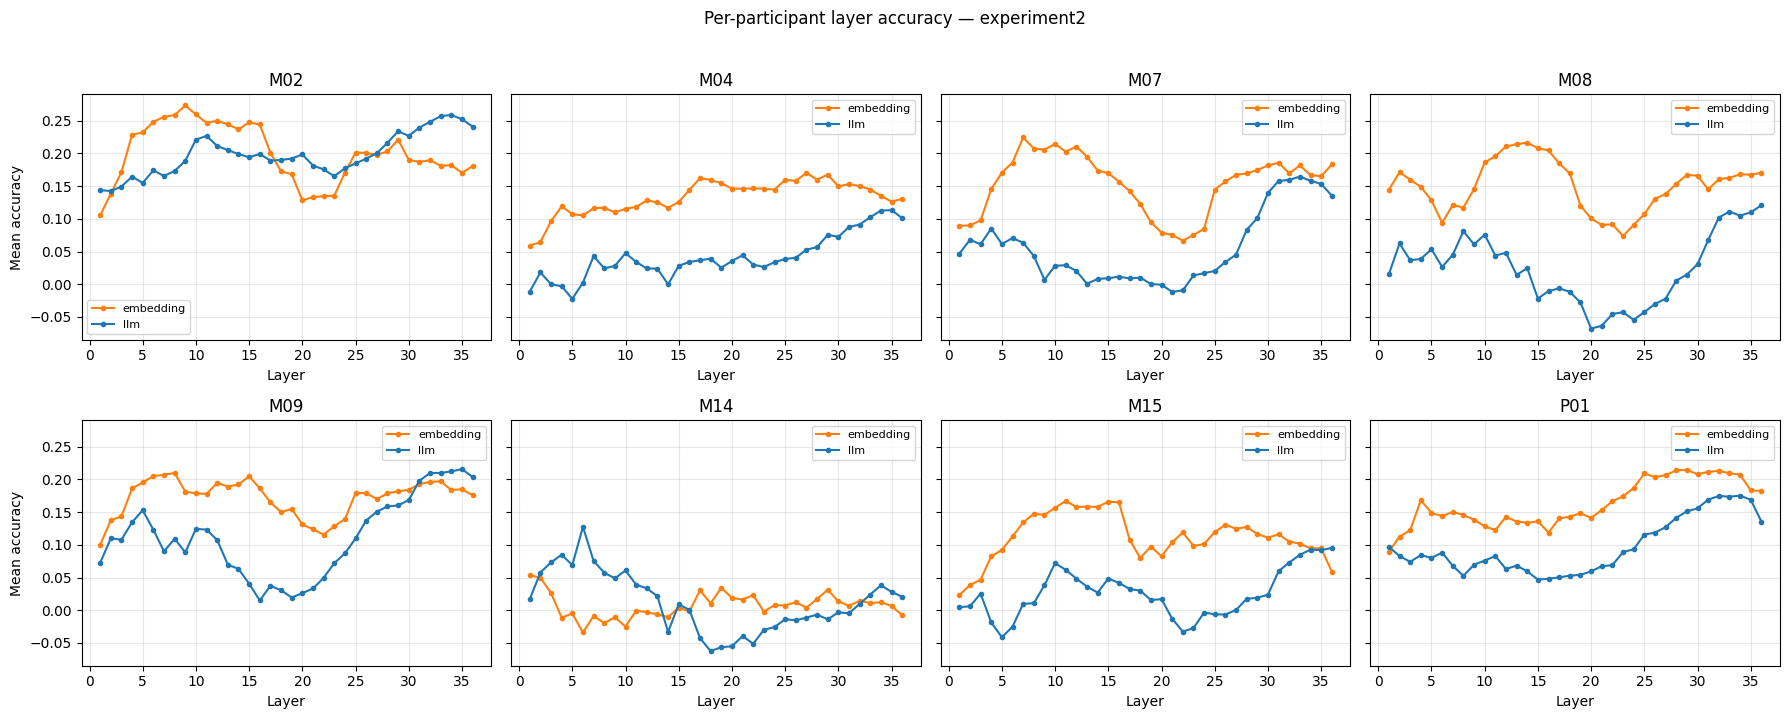

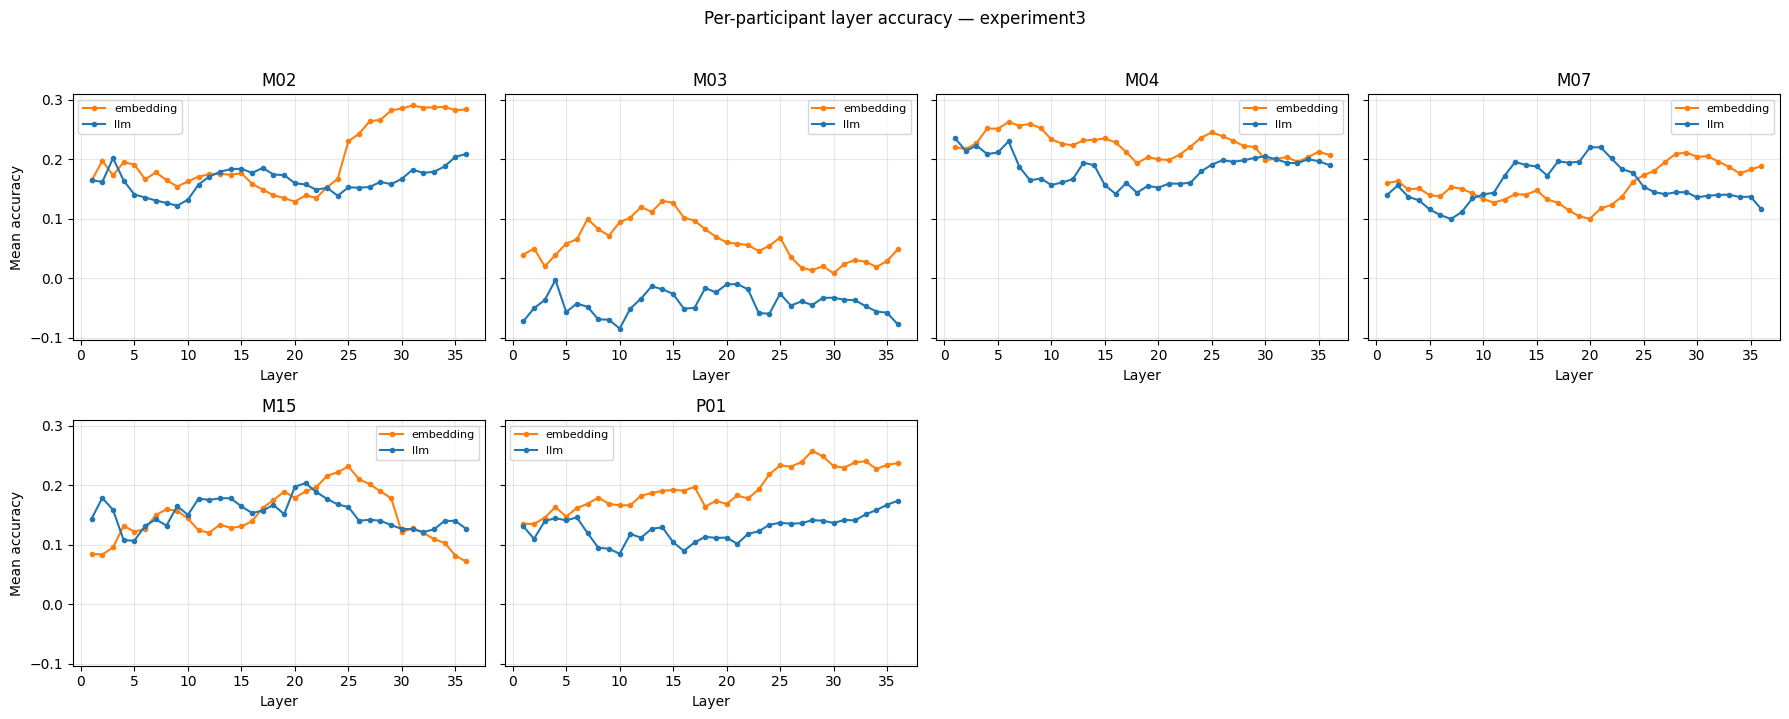

In [3]:
# Per participant results
colors = {"llm": "tab:blue", "embedding": "tab:orange"}
styles = {"default": "-", "mean": "-", "last": "--"}

for exp in experiments:
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})
    n_p = len(exp_participants)
    n_cols = min(4, n_p)
    n_rows = (n_p + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows),
                             sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for i, p in enumerate(exp_participants):
        ax = axes[i]
        for model in models:
            for pool in poolings:
                key = (exp, p, model, pool)
                if key not in runs:
                    continue
                curve = layer_curve(runs[key])
                label = model if pool == "default" else f"{model} ({pool})"
                ax.plot(layer_indices(len(curve)), curve,
                        color=colors.get(model, "gray"),
                        linestyle=styles.get(pool, "-"),
                        marker="o", markersize=3, label=label)
        ax.set_title(p)
        ax.set_xlabel("Layer")
        ax.grid(alpha=0.3)
        if i % n_cols == 0:
            ax.set_ylabel("Mean accuracy")
        ax.legend(fontsize=8)

    for j in range(n_p, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Per-participant layer accuracy — {exp}", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"per_participant_curves_{exp}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

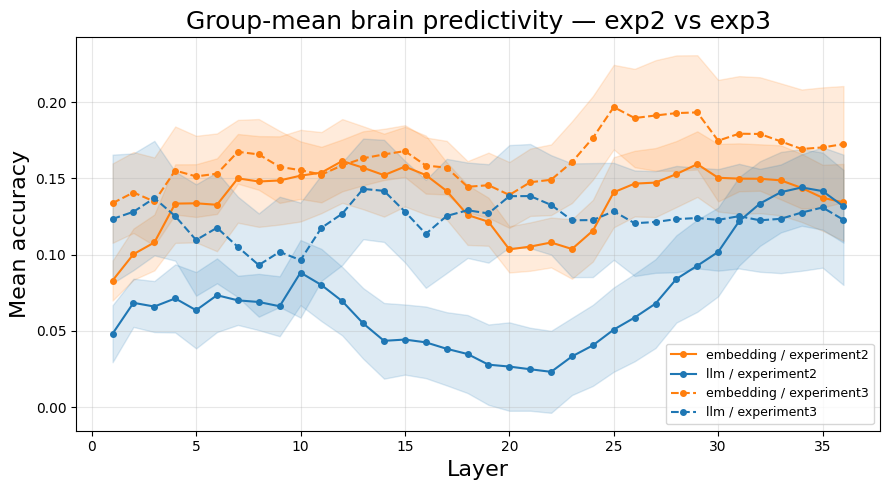

In [4]:
# Group mean curves
exp_styles = {"experiment2": "-", "experiment3": "--"}

fig, ax = plt.subplots(figsize=(9, 5))

for exp in experiments:
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})
    for model in models:
        for pool in poolings:
            curves = []
            for p in exp_participants:
                key = (exp, p, model, pool)
                if key in runs:
                    curves.append(layer_curve(runs[key]))
            if not curves:
                continue
            curves = np.stack(curves)
            mean = curves.mean(axis=0)
            sem = curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])

            label_bits = [model, exp]
            if pool != "default":
                label_bits.append(pool)
            label = " / ".join(label_bits)

            color = colors.get(model, "gray")
            ls = exp_styles.get(exp, "-")
            x = layer_indices(len(mean))
            ax.plot(x, mean, marker="o", markersize=4,
                    color=color, linestyle=ls, label=label)
            ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.15)

ax.set_xlabel("Layer", fontsize=16)
ax.set_ylabel("Mean accuracy", fontsize=16)
ax.set_title("Group-mean brain predictivity — exp2 vs exp3", fontsize=18)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "group_mean_curves_exp2_vs_exp3.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Per-participant peak accuracy table and model comparison.
# Shows each participant's best layer per model, plus the delta.

peak_records = defaultdict(dict)
layer_offset = 1 if SKIP_EMBEDDING_LAYER else 0

for exp in experiments:
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})

    print(f"\n=== {exp} ===")
    print(f"{'Participant':<12} {'LLM peak':>10} {'L':>3}   "
          f"{'Emb peak':>10} {'L':>3}   {'Delta':>8}")
    print("-" * 60)

    for p in exp_participants:
        for model in models:
            for pool in poolings:
                key = (exp, p, model, pool)
                if key in runs:
                    curve = layer_curve(runs[key])
                    best_idx = int(np.argmax(curve))
                    best_layer = best_idx + layer_offset
                    peak_records[(exp, p)][model] = (curve[best_idx], best_layer)
                    break

        llm_val, llm_lyr = peak_records[(exp, p)].get("llm", (np.nan, -1))
        emb_val, emb_lyr = peak_records[(exp, p)].get("embedding", (np.nan, -1))
        delta = emb_val - llm_val
        print(f"{p:<12} {llm_val:>10.3f} {llm_lyr:>3}   "
              f"{emb_val:>10.3f} {emb_lyr:>3}   {delta:>+8.3f}")


=== experiment2 ===
Participant    LLM peak   L     Emb peak   L      Delta
------------------------------------------------------------
M02               0.259  34        0.273   9     +0.014
M04               0.113  35        0.170  27     +0.057
M07               0.165  33        0.224   7     +0.060
M08               0.121  36        0.217  14     +0.096
M09               0.216  35        0.210   8     -0.006
M14               0.128   6        0.054   1     -0.074
M15               0.095  36        0.167  11     +0.072
P01               0.175  34        0.215  29     +0.039

=== experiment3 ===
Participant    LLM peak   L     Emb peak   L      Delta
------------------------------------------------------------
M02               0.209  36        0.290  31     +0.081
M03              -0.003   4        0.130  14     +0.133
M04               0.235   1        0.263   6     +0.027
M07               0.220  20        0.211  29     -0.009
M15               0.203  21        0.231  25     +0.

In [6]:
# One sided wilcoxon test
for exp in experiments:
    print(f"\n=== {exp} ===")
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})
    llm_peaks, emb_peaks = [], []
    for p in exp_participants:
        # adapt this to however peak_records is keyed; if you rebuild it
        # from `runs`, key it on (exp, p, model, pool) too
        if "llm" in peak_records[(exp, p)] and "embedding" in peak_records[(exp, p)]:
            llm_peaks.append(peak_records[(exp, p)]["llm"][0])
            emb_peaks.append(peak_records[(exp, p)]["embedding"][0])

    llm_peaks = np.array(llm_peaks)
    emb_peaks = np.array(emb_peaks)
    print(f"N participants with both models: {len(llm_peaks)}")
    if len(llm_peaks) >= 3:
        stat, pval_two = wilcoxon(emb_peaks, llm_peaks, alternative="two-sided")
        _, pval_greater = wilcoxon(emb_peaks, llm_peaks, alternative="greater")
        print(f"Wilcoxon (two-sided): W={stat:.2f}, p={pval_two:.4f}")
        print(f"Wilcoxon (emb > llm): p={pval_greater:.4f}")


=== experiment2 ===
N participants with both models: 8
Wilcoxon (two-sided): W=8.00, p=0.1953
Wilcoxon (emb > llm): p=0.0977

=== experiment3 ===
N participants with both models: 6
Wilcoxon (two-sided): W=1.00, p=0.0625
Wilcoxon (emb > llm): p=0.0312


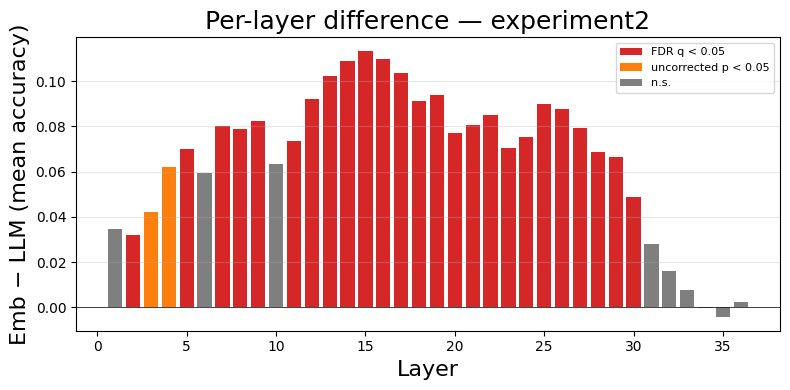


[experiment2] Layers significant after BH-FDR correction (q < 0.05):
  layer  2: delta=+0.032, p_raw=0.0195, p_adj=0.0293
  layer  5: delta=+0.070, p_raw=0.0195, p_adj=0.0293
  layer  7: delta=+0.080, p_raw=0.0273, p_adj=0.0394
  layer  8: delta=+0.079, p_raw=0.0117, p_adj=0.0211
  layer  9: delta=+0.083, p_raw=0.0078, p_adj=0.0165
  layer 11: delta=+0.074, p_raw=0.0195, p_adj=0.0293
  layer 12: delta=+0.092, p_raw=0.0078, p_adj=0.0165
  layer 13: delta=+0.102, p_raw=0.0078, p_adj=0.0165
  layer 14: delta=+0.109, p_raw=0.0039, p_adj=0.0165
  layer 15: delta=+0.113, p_raw=0.0078, p_adj=0.0165
  layer 16: delta=+0.110, p_raw=0.0078, p_adj=0.0165
  layer 17: delta=+0.104, p_raw=0.0039, p_adj=0.0165
  layer 18: delta=+0.091, p_raw=0.0078, p_adj=0.0165
  layer 19: delta=+0.094, p_raw=0.0078, p_adj=0.0165
  layer 20: delta=+0.077, p_raw=0.0117, p_adj=0.0211
  layer 21: delta=+0.080, p_raw=0.0078, p_adj=0.0165
  layer 22: delta=+0.085, p_raw=0.0078, p_adj=0.0165
  layer 23: delta=+0.070, p_r

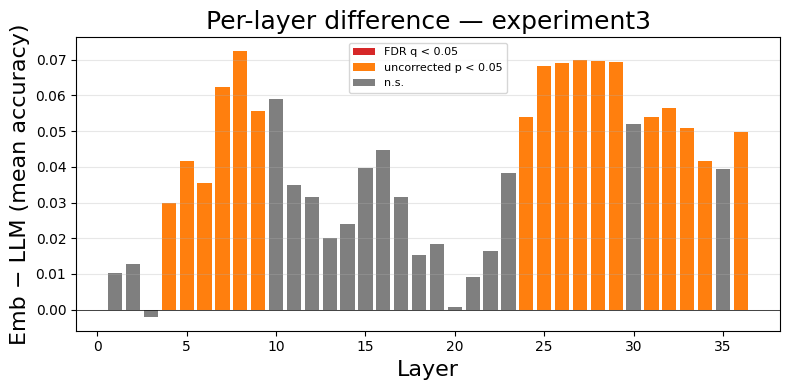


[experiment3] Layers significant after BH-FDR correction (q < 0.05):
  (none)

[experiment3] Layers with uncorrected p < 0.05 but NOT surviving FDR:
  layer  4: delta=+0.030, p_raw=0.0156
  layer  5: delta=+0.042, p_raw=0.0156
  layer  6: delta=+0.035, p_raw=0.0312
  layer  7: delta=+0.062, p_raw=0.0156
  layer  8: delta=+0.073, p_raw=0.0156
  layer  9: delta=+0.056, p_raw=0.0312
  layer 24: delta=+0.054, p_raw=0.0312
  layer 25: delta=+0.068, p_raw=0.0156
  layer 26: delta=+0.069, p_raw=0.0156
  layer 27: delta=+0.070, p_raw=0.0156
  layer 28: delta=+0.070, p_raw=0.0156
  layer 29: delta=+0.069, p_raw=0.0156
  layer 31: delta=+0.054, p_raw=0.0156
  layer 32: delta=+0.057, p_raw=0.0312
  layer 33: delta=+0.051, p_raw=0.0469
  layer 34: delta=+0.042, p_raw=0.0469
  layer 36: delta=+0.050, p_raw=0.0469


In [7]:
# Wilcoxon test per layer, with FDR correction
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

pool = poolings[0]

for exp in experiments:
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})
    llm_curves, emb_curves = [], []
    for p in exp_participants:
        if (exp, p, "llm", pool) in runs and (exp, p, "embedding", pool) in runs:
            llm_curves.append(layer_curve(runs[(exp, p, "llm", pool)]))
            emb_curves.append(layer_curve(runs[(exp, p, "embedding", pool)]))
    if not llm_curves:
        continue
    llm_curves = np.stack(llm_curves)
    emb_curves = np.stack(emb_curves)

    n_layers = llm_curves.shape[1]
    pvals = np.ones(n_layers)
    for layer in range(n_layers):
        if len(llm_curves) >= 3:
            _, pv = wilcoxon(emb_curves[:, layer], llm_curves[:, layer],
                             alternative="greater")
            pvals[layer] = pv

    # Benjamini-Hochberg FDR correction across layers
    reject_fdr, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 4))
    mean_delta = emb_curves.mean(0) - llm_curves.mean(0)
    x = layer_indices(n_layers)

    bar_colors = []
    for pv_raw, sig_fdr in zip(pvals, reject_fdr):
        if sig_fdr:
            bar_colors.append("tab:red")
        elif pv_raw < 0.05:
            bar_colors.append("tab:orange")
        else:
            bar_colors.append("tab:gray")

    ax.bar(x, mean_delta, color=bar_colors)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Layer", fontsize=16)
    ax.set_ylabel("Emb − LLM (mean accuracy)", fontsize=16)
    ax.set_title(f"Per-layer difference — {exp}", fontsize=18)
    ax.grid(alpha=0.3, axis="y")

    ax.legend(handles=[
        Patch(facecolor="tab:red",    label="FDR q < 0.05"),
        Patch(facecolor="tab:orange", label="uncorrected p < 0.05"),
        Patch(facecolor="tab:gray",   label="n.s."),
    ], loc="best", fontsize=8)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"per_layer_delta_{exp}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- Report ---
    print(f"\n[{exp}] Layers significant after BH-FDR correction (q < 0.05):")
    any_sig = False
    for i, (pv_raw, pv_adj, sig) in enumerate(zip(pvals, pvals_fdr, reject_fdr)):
        if sig:
            any_sig = True
            L = i + layer_offset
            print(f"  layer {L:2d}: delta={mean_delta[i]:+.3f}, "
                  f"p_raw={pv_raw:.4f}, p_adj={pv_adj:.4f}")
    if not any_sig:
        print("  (none)")

    print(f"\n[{exp}] Layers with uncorrected p < 0.05 but NOT surviving FDR:")
    for i, (pv_raw, sig) in enumerate(zip(pvals, reject_fdr)):
        if pv_raw < 0.05 and not sig:
            L = i + layer_offset
            print(f"  layer {L:2d}: delta={mean_delta[i]:+.3f}, p_raw={pv_raw:.4f}")

/scratch-local/62678/ipykernel_1377959/1961125058.py:33: RuntimeWarning: Mean of empty slice
  curve = np.nanmean(accs_test, axis=(1, 2))


M02_qwen3-4b-embedding_passages_DMN
M02_qwen3-4b-embedding_passages_DMN: peak r = 0.168 at layer 35/36
M02_qwen3-4b-embedding_passages_MD
M02_qwen3-4b-embedding_passages_MD: peak r = 0.089 at layer 36/36
M02_qwen3-4b-embedding_passages_aal_1ofN
M02_qwen3-4b-embedding_passages_aal_1ofN: peak r = 0.119 at layer 36/36
M02_qwen3-4b-embedding_passages_gordon
M02_qwen3-4b-embedding_passages_gordon: peak r = 0.141 at layer 36/36
M02_qwen3-4b-embedding_passages_languageLH
M02_qwen3-4b-embedding_passages_languageLH: peak r = 0.290 at layer 31/36
M02_qwen3-4b-embedding_passages_languageParcelsConservative_aal
M02_qwen3-4b-embedding_passages_languageParcelsConservative_aal: peak r = 0.281 at layer 31/36
M02_qwen3-4b-embedding_passages_languageParcels_aal
M02_qwen3-4b-embedding_passages_languageParcels_aal: peak r = 0.177 at layer 36/36
M02_qwen3-4b-embedding_passages_languageRH
M02_qwen3-4b-embedding_passages_languageRH: peak r = 0.180 at layer 33/36
M02_qwen3-4b-embedding_passages_multipleDemand

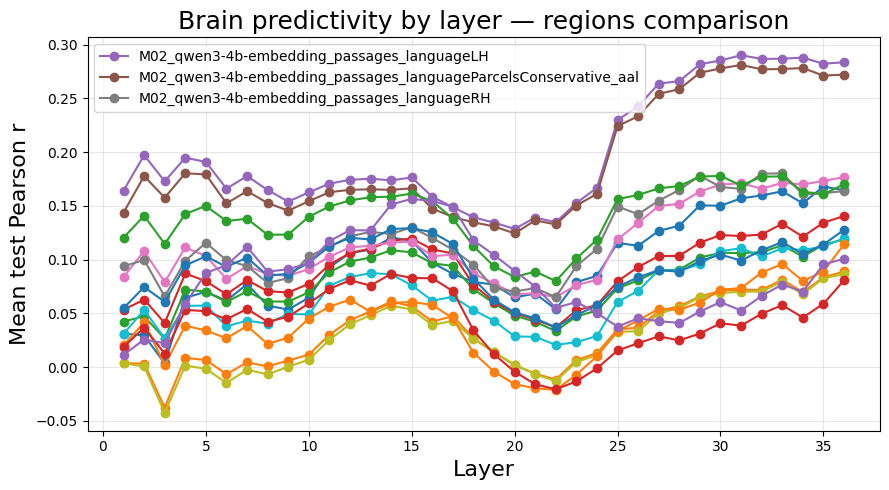

In [8]:
# All region comparison for M02
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# results/ is one level up from Visualisation/
REGIONS_DIR = Path("..") / "results" / "regions"

plt.figure(figsize=(9, 5))

# only these will appear in legend
legend_keep = {
    "M02_qwen3-4b-embedding_passages_languageLH",
    "M02_qwen3-4b-embedding_passages_languageParcelsConservative_aal",
    "M02_qwen3-4b-embedding_passages_languageRH"
}

# iterate over all subfolders in results/regions/
for region_dir in sorted(REGIONS_DIR.iterdir()):
    if not region_dir.is_dir():
        continue

    path = region_dir / "layer_accuracies.npz"
    if not path.exists():
        print(f"Skipping {region_dir.name} (no layer_accuracies.npz)")
        continue

    label = region_dir.name

    accs_test = np.load(path)["accs_test"]  # (n_layers, n_splits, n_voxels)

    # FIX 1: ignore NaNs properly
    curve = np.nanmean(accs_test, axis=(1, 2))

    # FIX 2: skip completely invalid curves
    if np.all(np.isnan(curve)):
        print(f"{label}: all NaN, skipping")
        continue

    # FIX 3: safe peak detection
    best = int(np.nanargmax(curve))
    print(label)
    # plotting (legend filtered)
    if label in legend_keep:
        plt.plot(range(len(curve)), curve, marker="o", label=label)
    else:
        plt.plot(range(len(curve)), curve, marker="o", label="_nolegend_")

    print(f"{label}: peak r = {curve[best]:.3f} at layer {best}/{len(curve) - 1}")

plt.xlabel("Layer", fontsize=16)
plt.ylabel("Mean test Pearson r", fontsize=16)
plt.title("Brain predictivity by layer — regions comparison", fontsize=18)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

embedding (normal): peak r = 0.197 at layer 24
embedding (scrambled): peak r = 0.158 at layer 15


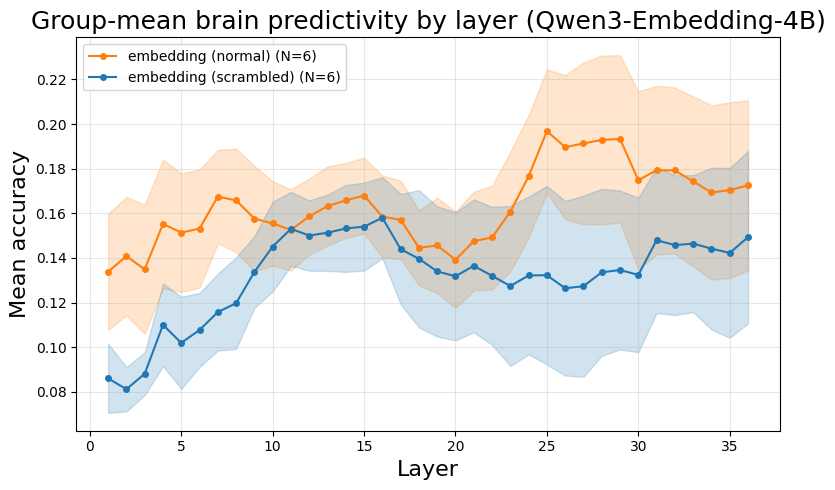

In [10]:
# Scrambled passages.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..") / "results"
NORMAL_DIR = BASE_DIR / "experiment3"
SCRAMBLE_DIR = BASE_DIR / "scramble"
FIGURES_DIR = Path(".") / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

SKIP_EMBEDDING_LAYER = True   # drop layer 0 (returns NaN on our data)

def layer_curve(accs_test):
    """Mean accuracy per layer, optionally skipping layer 0."""
    curve = accs_test.mean(axis=(1, 2))
    if SKIP_EMBEDDING_LAYER:
        curve = curve[1:]
    return curve

def layer_indices(n_layers):
    """x-axis indices matching layer_curve output."""
    return np.arange(1, n_layers + 1) if SKIP_EMBEDDING_LAYER else np.arange(n_layers)


def collect_curves(parent_dir, include_keyword=None):
    curves = []

    for run_dir in sorted(parent_dir.iterdir()):
        if not run_dir.is_dir():
            continue

        # --- filter: only include runs matching keyword (e.g. embedding) ---
        if include_keyword and include_keyword not in run_dir.name:
            continue

        path = run_dir / "layer_accuracies.npz"
        if not path.exists():
            continue

        accs_test = np.load(path)["accs_test"]
        curve = layer_curve(accs_test)
        curves.append(curve)

    if not curves:
        return None

    return np.stack(curves)  # (n_runs, n_layers)


# --- collect both groups (embedding only) ---
normal_curves = collect_curves(
    NORMAL_DIR,
    include_keyword="embedding"
)

scramble_curves = collect_curves(
    SCRAMBLE_DIR,
    include_keyword="embedding"
)


# Same blue/orange palette as the reference figure
condition_colors = {"normal": "C1", "scrambled": "C0"}

fig, ax = plt.subplots(figsize=(8, 5))

def plot_group(curves, label, color, linestyle="-"):
    if curves is None:
        print(f"No data for {label}")
        return

    mean = curves.mean(axis=0)
    sem = curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])

    x = layer_indices(len(mean))

    ax.plot(
        x, mean,
        marker="o",
        markersize=4,
        color=color,
        linestyle=linestyle,
        label=f"{label} (N={curves.shape[0]})"
    )

    ax.fill_between(
        x,
        mean - sem,
        mean + sem,
        color=color,
        alpha=0.2
    )

    best = int(np.argmax(mean))
    print(f"{label}: peak r = {mean[best]:.3f} at layer {best}")


# --- plot both ---
plot_group(normal_curves, "embedding (normal)",
           condition_colors["normal"])
plot_group(scramble_curves, "embedding (scrambled)",
           condition_colors["scrambled"])

ax.set_xlabel("Layer", fontsize=16)
ax.set_ylabel("Mean accuracy", fontsize=16)
ax.set_title("Group-mean brain predictivity by layer (Qwen3-Embedding-4B)",
             fontsize=18)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "group_mean_curves_embedding.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# intrinsic dimensionality analysis
import sys
sys.path.insert(0, str(Path("..").resolve()))

from src.intrinsic_dim import compute_id_per_layer
from src.embedding import load_embeddings
from scipy.stats import spearmanr

DATA_DIR = Path("..") / "data"
ID_RESULTS_DIR = Path("..") / "results" / "intrinsic_dim"

def get_id_curve(experiment, participant, model_key):
    tag = f"{participant}_qwen3-4b-{model_key}_passages"

    # try precomputed first
    precomp = ID_RESULTS_DIR / experiment / tag / "intrinsic_dim.npz"
    if precomp.exists():
        data = np.load(precomp)
        id_vals = data["id_values"]
        if SKIP_EMBEDDING_LAYER:
            id_vals = id_vals[1:]
        return id_vals

    # otherwise compute from embeddings
    emb_path = DATA_DIR / experiment / f"{tag}.npz"
    if not emb_path.exists():
        return None
    layer_emb, _ = load_embeddings(emb_path)
    id_vals = compute_id_per_layer(layer_emb)
    if SKIP_EMBEDDING_LAYER:
        id_vals = id_vals[1:]
    return id_vals


id_curves = {}  # (experiment, participant, model) -> 1d array
for exp in experiments:
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})
    for p in exp_participants:
        for model_key in ["llm", "embedding"]:
            curve = get_id_curve(exp, p, model_key)
            if curve is not None:
                id_curves[(exp, p, model_key)] = curve

print(f"Loaded/computed I_d for {len(id_curves)} runs")

In [ ]:
# group mean I_d curves
fig, axes = plt.subplots(1, len(experiments), figsize=(7 * len(experiments), 5),
                         sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp in zip(axes, experiments):
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})

    for model_key, color in [("llm", "tab:blue"), ("embedding", "tab:orange")]:
        curves = []
        for p in exp_participants:
            if (exp, p, model_key) in id_curves:
                curves.append(id_curves[(exp, p, model_key)])
        if not curves:
            continue
        curves = np.stack(curves)
        mean = curves.mean(axis=0)
        sem = curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])
        x = layer_indices(len(mean))

        ax.plot(x, mean, marker="o", markersize=4, color=color,
                label=f"{model_key} (N={curves.shape[0]})")
        ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.15)

    ax.set_xlabel("Layer")
    ax.set_ylabel("Intrinsic dimensionality ($I_d$)")
    ax.set_title(f"Layer-wise $I_d$ — {exp}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "intrinsic_dim_llm_vs_embedding.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# overlay I_d and encoding performance on dual y-axis
pool = poolings[0]

fig, axes = plt.subplots(1, len(experiments), figsize=(7 * len(experiments), 5))
if len(experiments) == 1:
    axes = [axes]

for ax, exp in zip(axes, experiments):
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})

    for model_key, color in [("llm", "tab:blue"), ("embedding", "tab:orange")]:
        enc_curves = []
        for p in exp_participants:
            key = (exp, p, model_key, pool)
            if key in runs:
                enc_curves.append(layer_curve(runs[key]))
        if not enc_curves:
            continue
        enc_mean = np.stack(enc_curves).mean(axis=0)

        id_cs = []
        for p in exp_participants:
            if (exp, p, model_key) in id_curves:
                id_cs.append(id_curves[(exp, p, model_key)])
        if not id_cs:
            continue
        id_mean = np.stack(id_cs).mean(axis=0)

        x = layer_indices(len(enc_mean))
        ax.plot(x, enc_mean, marker="o", markersize=4, color=color,
                linestyle="-", label=f"{model_key} encoding")

        ax2 = ax.twinx()
        ax2.plot(x, id_mean, marker="s", markersize=4, color=color,
                 linestyle="--", alpha=0.7, label=f"{model_key} $I_d$")
        ax2.set_ylabel("$I_d$", color="gray")
        ax2.tick_params(axis="y", labelcolor="gray")

    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean encoding accuracy")
    ax.set_title(f"Encoding vs $I_d$ — {exp}")
    ax.grid(alpha=0.3)

    # combined legend from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "encoding_vs_intrinsic_dim.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# spearman correlation between I_d and encoding performance per participant
pool = poolings[0]

print("Spearman rho: layer-wise I_d vs encoding performance\n")
print(f"{'Experiment':<15} {'Model':<12} {'Participant':<12} {'rho':>6} {'p':>8}")
print("-" * 60)

all_rhos = {"llm": [], "embedding": []}

for exp in experiments:
    exp_participants = sorted({k[1] for k in runs if k[0] == exp})
    for model_key in ["llm", "embedding"]:
        for p in exp_participants:
            enc_key = (exp, p, model_key, pool)
            id_key = (exp, p, model_key)
            if enc_key not in runs or id_key not in id_curves:
                continue
            enc = layer_curve(runs[enc_key])
            id_vals = id_curves[id_key]
            n = min(len(enc), len(id_vals))
            rho, pval = spearmanr(id_vals[:n], enc[:n])
            all_rhos[model_key].append(rho)
            print(f"{exp:<15} {model_key:<12} {p:<12} {rho:>6.3f} {pval:>8.4f}")

print()
for model_key in ["llm", "embedding"]:
    rhos = all_rhos[model_key]
    if rhos:
        print(f"Mean rho ({model_key}): {np.mean(rhos):.3f} "
              f"(N={len(rhos)}, std={np.std(rhos, ddof=1):.3f})")